## 1. Setup and Imports

In [58]:
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
import replicate
import os
import sys
import io
import base64
import json

# Add project root to path to import from scripts
PROJECT_ROOT = Path("/Users/Cecilia/Documents/Programación/archive_filter")
sys.path.insert(0, str(PROJECT_ROOT))

# Import the working YOLO detection function
from scripts.preprocessing.process_objects_yolo import detect_objects_yolo, parse_yolo_output

# Set up paths
BASE_DIR = PROJECT_ROOT
FRAMES_DIR = BASE_DIR / "data" / "frames"
OUTPUT_DIR = BASE_DIR / "data" / "objects"

print("Libraries imported successfully!")
print(f"Base directory: {BASE_DIR}")
print(f"Frames directory: {FRAMES_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print("\n✓ Imported working YOLO detection function from process_objects_yolo.py")

Libraries imported successfully!
Base directory: /Users/Cecilia/Documents/Programación/archive_filter
Frames directory: /Users/Cecilia/Documents/Programación/archive_filter/data/frames
Output directory: /Users/Cecilia/Documents/Programación/archive_filter/data/objects

✓ Imported working YOLO detection function from process_objects_yolo.py


## 2. Setup Replicate YOLO World Model

In [59]:
# Setup Replicate API
# Make sure you have REPLICATE_API_TOKEN set in your environment
# export REPLICATE_API_TOKEN=your_token_here

MODEL_VERSION = "franz-biz/yolo-world-xl:fd1305d3fc19e81540542f51c2530cf8f393e28cc6ff4976337c3e2b75c7c292"

print(f"Using Replicate YOLO World XL model")
print(f"Model: {MODEL_VERSION}")
print("\nNote: YOLO World is a zero-shot object detector.")
print("You can specify custom classes at inference time!")
print("\nCommon classes: person, car, dog, cat, bicycle, motorcycle, bus, truck, etc.")

Using Replicate YOLO World XL model
Model: franz-biz/yolo-world-xl:fd1305d3fc19e81540542f51c2530cf8f393e28cc6ff4976337c3e2b75c7c292

Note: YOLO World is a zero-shot object detector.
You can specify custom classes at inference time!

Common classes: person, car, dog, cat, bicycle, motorcycle, bus, truck, etc.


## 3. Helper Functions

In [60]:
def load_frame(frame_path):
    """Load a single frame from path."""
    frame = cv2.imread(str(frame_path))
    if frame is None:
        raise ValueError(f"Could not load frame from {frame_path}")
    # Convert BGR to RGB for display
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


def detect_objects(frame_path, target_classes=None, confidence_threshold=0.5):
    """
    Run YOLO World detection on a frame using the working function from process_objects_yolo.py
    
    Args:
        frame_path: Path to the frame image file
        target_classes: List of class names to detect (e.g., ['person', 'car', 'dog'])
        confidence_threshold: Minimum confidence score (0.0 to 1.0) - Note: ignored, using 0.01 from working code
    
    Returns:
        List of detections with format:
        [{
            'bbox': [x1, y1, x2, y2],
            'confidence': float,
            'class': str
        }, ...]
    """
    if target_classes is None or len(target_classes) == 0:
        raise ValueError("target_classes is required for YOLO World! Specify classes like ['person', 'car', 'dog']")
    
    # Use the working function from process_objects_yolo.py
    print(f"Running detection for classes: {target_classes}...")
    detections_raw = detect_objects_yolo(frame_path, target_classes)
    
    # Convert format from working code to our format
    detections = []
    for det in detections_raw:
        detections.append({
            'bbox': det['bbox'],  # Already in [x1, y1, x2, y2] format
            'confidence': det['score'],
            'class': det['class']
        })
    
    print(f"Detected {len(detections)} objects")
    return detections


def crop_object(frame, bbox, padding=10):
    """
    Crop object from frame using bounding box.
    
    Args:
        frame: Image array (RGB format)
        bbox: [x1, y1, x2, y2]
        padding: Pixels to add around the bbox
    
    Returns:
        Cropped image array
    """
    h, w = frame.shape[:2]
    x1, y1, x2, y2 = [int(coord) for coord in bbox]
    
    # Add padding
    x1 = max(0, x1 - padding)
    y1 = max(0, y1 - padding)
    x2 = min(w, x2 + padding)
    y2 = min(h, y2 + padding)
    
    return frame[y1:y2, x1:x2]


def visualize_detections(frame, detections, figsize=(15, 10)):
    """
    Visualize detections on the frame.
    
    Args:
        frame: Image array (RGB format)
        detections: List of detection dictionaries
        figsize: Figure size for matplotlib
    """
    fig, ax = plt.subplots(1, figsize=figsize)
    ax.imshow(frame)
    
    # Draw bounding boxes
    for det in detections:
        x1, y1, x2, y2 = det['bbox']
        width = x2 - x1
        height = y2 - y1
        
        # Create rectangle
        rect = Rectangle((x1, y1), width, height, 
                        linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        
        # Add label
        label = f"{det['class']}: {det['confidence']:.2f}"
        ax.text(x1, y1 - 5, label, 
               bbox=dict(facecolor='red', alpha=0.7),
               fontsize=10, color='white')
    
    ax.axis('off')
    plt.title(f"Detected {len(detections)} objects")
    plt.tight_layout()
    plt.show()


def display_cropped_objects(frame, detections, max_cols=4):
    """
    Display all cropped objects in a grid.
    
    Args:
        frame: Image array (RGB format)
        detections: List of detection dictionaries
        max_cols: Maximum columns in the grid
    """
    if not detections:
        print("No objects detected")
        return
    
    n = len(detections)
    cols = min(n, max_cols)
    rows = (n + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    if n == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if n > cols else axes
    
    for idx, det in enumerate(detections):
        cropped = crop_object(frame, det['bbox'])
        axes[idx].imshow(cropped)
        axes[idx].set_title(f"{det['class']}\n{det['confidence']:.2f}")
        axes[idx].axis('off')
    
    # Hide unused subplots
    for idx in range(n, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()


print("Helper functions defined!")
print("✓ Using working detect_objects_yolo() from process_objects_yolo.py")

Helper functions defined!
✓ Using working detect_objects_yolo() from process_objects_yolo.py


## 4. Experiment: Single Frame Detection

Loaded frame: /Users/Cecilia/Documents/Programación/archive_filter/data/frames/video_CH27/frame_00003.jpg
Frame shape: (400, 220, 3)


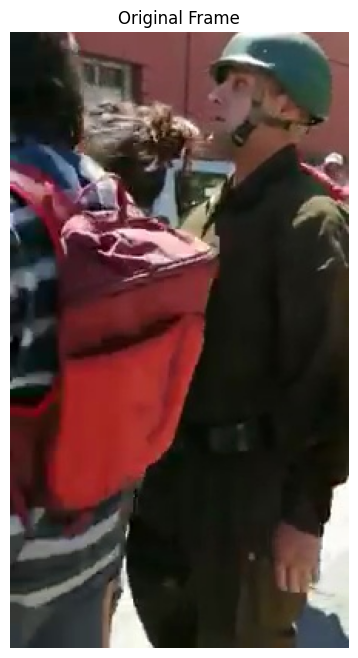

In [61]:
# Load a single frame
# Update this path to point to one of your frames
frame_path = FRAMES_DIR / "video_CH27/frame_00003.jpg"

if frame_path.exists():
    frame = load_frame(frame_path)
    print(f"Loaded frame: {frame_path}")
    print(f"Frame shape: {frame.shape}")
    
    # Display original frame
    plt.figure(figsize=(12, 8))
    plt.imshow(frame)
    plt.title("Original Frame")
    plt.axis('off')
    plt.show()
else:
    print(f"Frame not found: {frame_path}")
    print("Available videos:")
    for video_dir in FRAMES_DIR.iterdir():
        if video_dir.is_dir():
            print(f"  - {video_dir.name}")

In [62]:
# Run detection on multiple frames to find detections
# YOLO World is a zero-shot detector, so you must specify target classes
target_classes = ['person']  # Modify as needed

# Try first 10 frames from video_CH27
video_dir = FRAMES_DIR / "video_CH27"
frame_list = sorted(list(video_dir.glob("*.jpg")))[:10]

print(f"Testing detection on {len(frame_list)} frames from video_CH27...")
print("="*60)

all_detections_results = []

for idx, test_frame_path in enumerate(frame_list, 1):
    print(f"\n[{idx}/{len(frame_list)}] Testing: {test_frame_path.name}")
    
    try:
        detections = detect_objects(test_frame_path, target_classes=target_classes, confidence_threshold=0.01)
        
        all_detections_results.append({
            'frame_path': test_frame_path,
            'detections': detections
        })
        
        if detections:
            print(f"  ✓ Found {len(detections)} objects!")
            for i, det in enumerate(detections):
                print(f"    {i+1}. {det['class']} (confidence: {det['confidence']:.3f})")
                print(f"       BBox: {[int(x) for x in det['bbox']]}")
        else:
            print(f"  - No detections")
    except Exception as e:
        print(f"  ✗ Error: {e}")

# Summary
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
frames_with_detections = [r for r in all_detections_results if r['detections']]
total_detections = sum(len(r['detections']) for r in all_detections_results)

print(f"Frames tested: {len(all_detections_results)}")
print(f"Frames with detections: {len(frames_with_detections)}")
print(f"Total detections: {total_detections}")

if frames_with_detections:
    print(f"\nFrames with detections:")
    for r in frames_with_detections:
        print(f"  - {r['frame_path'].name}: {len(r['detections'])} objects")
    
    # Use the first frame with detections for visualization
    frame_path = frames_with_detections[0]['frame_path']
    detections = frames_with_detections[0]['detections']
    frame = load_frame(frame_path)
    print(f"\nUsing {frame_path.name} for visualization below...")
else:
    print("\n⚠ No detections found in any frame!")
    print("This might indicate:")
    print("  - The frames don't contain the target class ('person')")
    print("  - Try different classes: 'car', 'bicycle', 'building', etc.")
    print("  - The API might be having issues")

Testing detection on 10 frames from video_CH27...

[1/10] Testing: frame_00000.jpg
Running detection for classes: ['person']...
  Debug: Raw output keys: ['json_str', 'media_path']
  Debug: No detections found in output
Detected 0 objects
  - No detections

[2/10] Testing: frame_00001.jpg
Running detection for classes: ['person']...
  Debug: Raw output keys: ['json_str', 'media_path']
  Debug: No detections found in output
Detected 0 objects
  - No detections

[3/10] Testing: frame_00002.jpg
Running detection for classes: ['person']...
  Debug: Raw output keys: ['json_str', 'media_path']
  Debug: No detections found in output
Detected 0 objects
  - No detections

[4/10] Testing: frame_00003.jpg
Running detection for classes: ['person']...
  Debug: Raw output keys: ['json_str', 'media_path']
  Debug: No detections found in output
Detected 0 objects
  - No detections

[5/10] Testing: frame_00004.jpg
Running detection for classes: ['person']...
  Debug: Raw output keys: ['json_str', 'medi

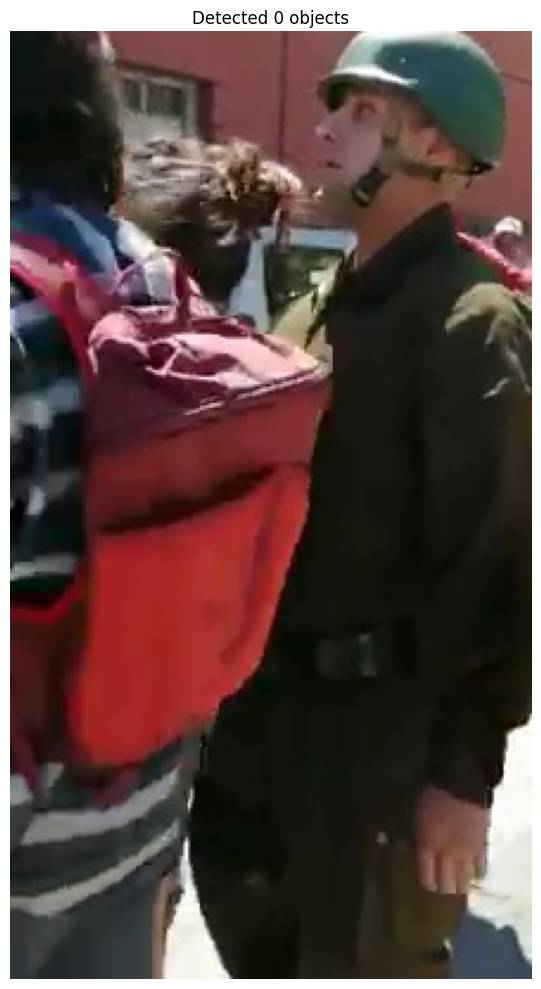

In [63]:
# Visualize detections with bounding boxes
visualize_detections(frame, detections)

In [64]:
# Display cropped objects
display_cropped_objects(frame, detections)

No objects detected


## 5. Experiment: Detect Specific Classes

In [65]:
# Detect only specific classes (e.g., person, car, dog)
target_classes = ['person', 'car', 'bicycle']  # Modify as needed

detections_filtered = detect_objects(
    frame_path,  # Pass path, not frame array
    target_classes=target_classes, 
    confidence_threshold=0.5
)

print(f"\nDetected {len(detections_filtered)} objects from classes {target_classes}:")
for i, det in enumerate(detections_filtered):
    print(f"  {i+1}. {det['class']} (confidence: {det['confidence']:.3f})")

# Visualize filtered results
if detections_filtered:
    visualize_detections(frame, detections_filtered)
    display_cropped_objects(frame, detections_filtered)
else:
    print("No objects detected for the specified classes.")

Running detection for classes: ['person', 'car', 'bicycle']...
  Debug: Raw output keys: ['json_str', 'media_path']
  Debug: No detections found in output
Detected 0 objects

Detected 0 objects from classes ['person', 'car', 'bicycle']:
No objects detected for the specified classes.


## 6. Experiment: Multiple Frames Processing

In [66]:
# Process multiple frames from a video
video_name = "video_1"  # Change to your video name
video_frames_dir = FRAMES_DIR / video_name

# Get first N frames
n_frames = 5
frame_paths = sorted(list(video_frames_dir.glob("*.jpg")))[:n_frames]

print(f"Processing {len(frame_paths)} frames from {video_name}...")

# Define classes to detect
target_classes = ['person', 'car', 'bicycle', 'dog']  # Modify as needed

# Store results for all frames
all_results = []

for frame_path in frame_paths:
    frame = load_frame(frame_path)
    detections = detect_objects(frame_path, target_classes=target_classes, confidence_threshold=0.5)
    
    all_results.append({
        'frame_path': frame_path,
        'frame': frame,
        'detections': detections
    })
    
    print(f"  {frame_path.name}: {len(detections)} objects detected")

print("\nProcessing complete!")

Processing 5 frames from video_1...
Running detection for classes: ['person', 'car', 'bicycle', 'dog']...
  Debug: Raw output keys: ['json_str', 'media_path']
  Debug: No detections found in output
Detected 0 objects
  video_1_frame_00001.jpg: 0 objects detected
Running detection for classes: ['person', 'car', 'bicycle', 'dog']...
  Debug: Raw output keys: ['json_str', 'media_path']
  Debug: No detections found in output
Detected 0 objects
  video_1_frame_00002.jpg: 0 objects detected
Running detection for classes: ['person', 'car', 'bicycle', 'dog']...
  Debug: Raw output keys: ['json_str', 'media_path']
  Debug: No detections found in output
Detected 0 objects
  video_1_frame_00003.jpg: 0 objects detected
Running detection for classes: ['person', 'car', 'bicycle', 'dog']...
  Debug: Raw output keys: ['json_str', 'media_path']
  Debug: No detections found in output
Detected 0 objects
  video_1_frame_00004.jpg: 0 objects detected
Running detection for classes: ['person', 'car', 'bicycl

In [67]:
# Visualize results from multiple frames
for result in all_results:
    print(f"\n{'='*60}")
    print(f"Frame: {result['frame_path'].name}")
    print(f"{'='*60}")
    
    if result['detections']:
        visualize_detections(result['frame'], result['detections'], figsize=(12, 8))
    else:
        print("No objects detected in this frame.")


Frame: video_1_frame_00001.jpg
No objects detected in this frame.

Frame: video_1_frame_00002.jpg
No objects detected in this frame.

Frame: video_1_frame_00003.jpg
No objects detected in this frame.

Frame: video_1_frame_00004.jpg
No objects detected in this frame.

Frame: video_1_frame_00005.jpg
No objects detected in this frame.


## 7. Export Cropped Objects

In [68]:
# Save cropped objects to disk
def save_cropped_objects(frame, detections, frame_name, output_dir, target_class=None):
    """
    Save cropped objects to disk.
    
    Args:
        frame: Image array (RGB format)
        detections: List of detection dictionaries
        frame_name: Name of the original frame
        output_dir: Directory to save cropped objects
        target_class: Only save objects of this class (None = all)
    
    Returns:
        List of saved file paths
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    saved_paths = []
    
    for idx, det in enumerate(detections):
        if target_class and det['class'] != target_class:
            continue
        
        # Crop object
        cropped = crop_object(frame, det['bbox'])
        
        # Create filename
        frame_stem = Path(frame_name).stem
        filename = f"{frame_stem}_{det['class']}_{idx}_{det['confidence']:.2f}.jpg"
        output_path = output_dir / filename
        
        # Convert RGB to BGR for OpenCV
        cropped_bgr = cv2.cvtColor(cropped, cv2.COLOR_RGB2BGR)
        cv2.imwrite(str(output_path), cropped_bgr)
        
        saved_paths.append(output_path)
    
    return saved_paths


# Example: Save objects from first frame
if all_results:
    result = all_results[0]
    output_dir = OUTPUT_DIR / "yolo_experiment"
    
    saved = save_cropped_objects(
        result['frame'],
        result['detections'],
        result['frame_path'].name,
        output_dir
    )
    
    print(f"Saved {len(saved)} cropped objects to {output_dir}")
    for path in saved:
        print(f"  - {path.name}")

Saved 0 cropped objects to /Users/Cecilia/Documents/Programación/archive_filter/data/objects/yolo_experiment


## 8. Summary Statistics

In [69]:
# Analyze detection statistics across all processed frames
from collections import Counter

if all_results:
    # Count detections per class
    class_counts = Counter()
    confidence_scores = []
    
    for result in all_results:
        for det in result['detections']:
            class_counts[det['class']] += 1
            confidence_scores.append(det['confidence'])
    
    print("\n" + "="*60)
    print("DETECTION SUMMARY")
    print("="*60)
    print(f"Total frames processed: {len(all_results)}")
    print(f"Total objects detected: {sum(class_counts.values())}")
    print(f"\nDetections by class:")
    for class_name, count in class_counts.most_common():
        print(f"  {class_name}: {count}")
    
    if confidence_scores:
        print(f"\nConfidence statistics:")
        print(f"  Mean: {np.mean(confidence_scores):.3f}")
        print(f"  Median: {np.median(confidence_scores):.3f}")
        print(f"  Min: {np.min(confidence_scores):.3f}")
        print(f"  Max: {np.max(confidence_scores):.3f}")
        
        # Plot confidence distribution
        plt.figure(figsize=(10, 5))
        plt.hist(confidence_scores, bins=20, edgecolor='black')
        plt.xlabel('Confidence Score')
        plt.ylabel('Frequency')
        plt.title('Distribution of Detection Confidence Scores')
        plt.grid(alpha=0.3)
        plt.show()


DETECTION SUMMARY
Total frames processed: 5
Total objects detected: 0

Detections by class:


## 9. Advanced: Batch Processing with Custom Parameters

In [70]:
def batch_process_frames(frame_paths, target_classes=None, 
                         confidence_threshold=0.5, save_crops=False, 
                         output_dir=None):
    """
    Process a batch of frames with YOLO World detection.
    
    Args:
        frame_paths: List of frame file paths
        target_classes: List of class names to detect (REQUIRED for YOLO World)
        confidence_threshold: Minimum confidence score
        save_crops: Whether to save cropped objects
        output_dir: Directory to save crops (required if save_crops=True)
    
    Returns:
        Dictionary with results and statistics
    """
    if target_classes is None or len(target_classes) == 0:
        raise ValueError("target_classes is required for YOLO World!")
    
    results = []
    class_counts = Counter()
    
    for frame_path in frame_paths:
        # Load and process frame
        frame = load_frame(frame_path)
        detections = detect_objects(
            frame_path,  # Pass path, not frame array
            target_classes=target_classes,
            confidence_threshold=confidence_threshold
        )
        
        # Save crops if requested
        if save_crops and output_dir and detections:
            save_cropped_objects(
                frame, detections, 
                frame_path.name, output_dir
            )
        
        # Update statistics
        for det in detections:
            class_counts[det['class']] += 1
        
        results.append({
            'frame_path': frame_path,
            'detections': detections
        })
    
    return {
        'results': results,
        'class_counts': dict(class_counts),
        'total_frames': len(frame_paths),
        'total_detections': sum(class_counts.values())
    }


# Example usage
video_name = "video_1"
video_frames_dir = FRAMES_DIR / video_name
frame_paths = sorted(list(video_frames_dir.glob("*.jpg")))[:10]

if frame_paths:
    print(f"Batch processing {len(frame_paths)} frames...")
    
    batch_results = batch_process_frames(
        frame_paths,
        target_classes=['person', 'car'],  # Detect only persons and cars
        confidence_threshold=0.6,
        save_crops=True,
        output_dir=OUTPUT_DIR / "yolo_batch_experiment"
    )
    
    print(f"\nBatch processing complete!")
    print(f"Total frames: {batch_results['total_frames']}")
    print(f"Total detections: {batch_results['total_detections']}")
    print(f"Detections by class: {batch_results['class_counts']}")
else:
    print(f"No frames found in {video_frames_dir}")

Batch processing 10 frames...
Running detection for classes: ['person', 'car']...
  Debug: Raw output keys: ['json_str', 'media_path']
  Debug: No detections found in output
Detected 0 objects
Running detection for classes: ['person', 'car']...
  Debug: Raw output keys: ['json_str', 'media_path']
  Debug: No detections found in output
Detected 0 objects
Running detection for classes: ['person', 'car']...
  Debug: Raw output keys: ['json_str', 'media_path']
  Debug: No detections found in output
Detected 0 objects
Running detection for classes: ['person', 'car']...
  Debug: Raw output keys: ['json_str', 'media_path']
  Debug: No detections found in output
Detected 0 objects
Running detection for classes: ['person', 'car']...
  Debug: Raw output keys: ['json_str', 'media_path']
  Debug: No detections found in output
Detected 0 objects
Running detection for classes: ['person', 'car']...
  Debug: Raw output keys: ['json_str', 'media_path']
  Debug: No detections found in output
Detected 0 